#  Baseline Feasibility Test for Change Prediction

Answer one prerequisite question: can the t-period balance sheet predict the t to t+1 financial change? This notebook only tests whether signal exists and does not train the final model and does not tune hyperparameters.

**Data**：`03_financial_change_labels.csv`, 81,603 company-period pair。

**Decision rule**

| Outcome | Interpretation | Next step |
|---|---|---|
| skill ≤ 0 & Spearman < 0.05 | no usable signal | -- |
| skill ≈ 0 but Spearman 0.05–0.15 | ranking-only signal | -- |
| skill > 0.05 or Spearman > 0.15 | real signal | proceed |
| B2 ≈ B3 | all signal is in sector & category | redesign |

jupyter nbconvert --to html "02 Data Modeling/baseline_change_prediction_feasibility.ipynb"

In [1]:
# Environment and global configuration

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
from scipy.stats import spearmanr
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import GroupKFold

warnings.filterwarnings("ignore", category=FutureWarning)

# Paths
DATA_PATH = Path("../01 EDA + Data PreProcessing/04_Five_CSV/03_financial_change_labels.csv")
OUT_DIR = Path("baseline_results")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# The 9 change metrics
METRICS = [
    "current_assets", "fixed_assets", "creditors_total", "equity",
    "net_assets_liabilities", "cash", "debtors", "employees",
    "total_assets_less_current_liabilities", "net_current_assets_liabilities",
    "profit_loss"
]

# Metadata visible at time t
META_FEATURES = ["primary_sector", "Accounts_AccountCategory", "evidence_tier_t"]

# Experiment parameters
N_SPLITS = 5              # number of CV folds
TIME_HOLDOUT_FRAC = 0.20  # time holdout fraction
MIN_GROUP_N = 30          # min group size for B2
MIN_ROWS = 200            # skip metrics with too few rows
RANDOM_STATE = 0

In [2]:
import warnings
warnings.filterwarnings(
    "ignore",
    message=".*sklearn.utils.parallel.delayed.*",
    category=UserWarning,
)

## 1. Load data and sanity check

- `CompanyNumber_norm` Must be read as string, otherwise leading zeros are lost.
- The grain is a pair, not a company. One company may contribute several rows, which is also why the split is grouped by company.

In [3]:
# Load
df = pd.read_csv(DATA_PATH, dtype={"CompanyNumber_norm": str}, low_memory=False)

for col in ["period_t", "period_t_plus_1", "available_date_t", "available_date_t_plus_1"]:
    df[col] = pd.to_datetime(df[col], errors="coerce")

n_rows, n_companies = len(df), df["CompanyNumber_norm"].nunique()
print(f"rows: {n_rows:,}")
print(f"companies: {n_companies:,}")
print(f"rows/companies : {n_rows / n_companies:.2f}")

# Eligibility coverage per metric
cov = pd.DataFrame({
    "metric": METRICS,
    "eligible_n": [int(df[f"{m}_change_eligible"].fillna(False).sum()) for m in METRICS],
})
cov["eligible_pct"] = (cov["eligible_n"] / n_rows).round(3)
cov["zero_change_pct"] = [
    round(float((df[f"{m}_signed_log_change"] == 0).sum()
                / max(df[f"{m}_change_eligible"].fillna(False).sum(), 1)), 3)
    for m in METRICS
]
print("\nCoverage and zero-change share")
print(cov.to_string(index=False))

rows: 81,603
companies: 76,611
rows/companies : 1.07

Coverage and zero-change share
                               metric  eligible_n  eligible_pct  zero_change_pct
                       current_assets       69809         0.855            0.049
                         fixed_assets       40192         0.493            0.240
                      creditors_total       74018         0.907            0.065
                               equity       78768         0.965            0.127
               net_assets_liabilities       67001         0.821            0.061
                                 cash       31753         0.389            0.041
                              debtors       26618         0.326            0.112
                            employees       76322         0.935            0.734
total_assets_less_current_liabilities       70435         0.863            0.062
       net_current_assets_liabilities       74815         0.917            0.055
                        

## 2. Feature construction (simplified)

Use only information visible at `available_date_t`.

Included：
- signed-log of the nine `_t` raw values & missing indicators
- `primary_sector`、`Accounts_AccountCategory`、`evidence_tier_t`
- month of `period_t`
- `gap_days`

excluded：
- Year or any linear time index.
- Any `_t_plus_1` / `_change_` / `_band` / `_threshold` column (all are t+1 information).

The next cell contains a hard assertion enforcing this whitelist.

In [4]:
def signed_log1p(x):
    """Sign-preserving log transform: sign(x)*ln(1+|x|)"""
    x = pd.to_numeric(x, errors="coerce")
    return np.sign(x) * np.log1p(np.abs(x))


# blacklist
FORBIDDEN_PATTERNS = ["_t_plus_1", "_change_", "_band", "_threshold", "percent_change"]


def build_features(frame, add_leak_column=None):
    """
    Build the time-t feature matrix.

    add_leak_column: Sanity check only — deliberately injects t+1 information.
    Returns: (X, categorical_column_indices)
    """
    X = pd.DataFrame(index=frame.index)

    # 9 t-period values & missing indicators
    for m in METRICS:
        X[f"{m}_t_sl"] = signed_log1p(frame[f"{m}_t"])
        X[f"{m}_t_missing"] = frame[f"{m}_t"].isna().astype(int)

    # time: month only, no year
    X["period_month"] = frame["period_t"].dt.month
    X["gap_days"] = frame["gap_days"]

    # categorical variables (-1 means missing)
    cat_idx = []
    for c in META_FEATURES:
        X[c] = frame[c].astype("category").cat.codes
        cat_idx.append(X.columns.get_loc(c))

    if add_leak_column is not None:
        X["__LEAK__"] = signed_log1p(frame[f"{add_leak_column}_t_plus_1"])

    # hard assertion
    bad = [c for c in X.columns if c != "__LEAK__"
           and any(p in c for p in FORBIDDEN_PATTERNS)]
    assert not bad, f"leaking features detected: {bad}"

    return X, cat_idx

# check
_X, _cat = build_features(df.head(100))
print(f"n_features : {_X.shape[1]}")
print(f"categorical: {[_X.columns[i] for i in _cat]}")

n_features : 27
categorical: ['primary_sector', 'Accounts_AccountCategory', 'evidence_tier_t']


In [5]:
_X.head()

,current_assets_t_sl,current_assets_t_missing,fixed_assets_t_sl,fixed_assets_t_missing,creditors_total_t_sl,creditors_total_t_missing,equity_t_sl,equity_t_missing,net_assets_liabilities_t_sl,net_assets_liabilities_t_missing,...,total_assets_less_current_liabilities_t_missing,net_current_assets_liabilities_t_sl,net_current_assets_liabilities_t_missing,profit_loss_t_sl,profit_loss_t_missing,period_month,gap_days,primary_sector,Accounts_AccountCategory,evidence_tier_t
0,11.046531,0,13.937082,0,10.848463,0,13.891398,0,13.891398,0,...,0,9.330077,0,11.158206,0,5,365.0,5,2,1
1,14.217877,0,13.708186,0,8.752423,0,14.565109,0,14.565109,0,...,0,14.065325,0,NaN,1,3,365.0,0,2,1
2,8.725345,0,3.970292,0,7.109879,0,8.514389,0,NaN,1,...,1,NaN,1,NaN,1,12,366.0,3,1,1
3,8.816408,0,NaN,1,6.613384,0,8.564840,0,8.564840,0,...,0,8.699515,0,NaN,1,12,365.0,3,1,1
4,4.234107,0,7.710205,0,NaN,1,7.740230,0,7.740230,0,...,0,4.234107,0,NaN,1,12,366.0,3,1,1


## 3. Four baselines

|  | Prediction | Meaning |
|---|---|---|
| **B0** | constant 0 | Assume no change. Since `sl(t+1) − sl(t) = 0` means value unchanged, this is the naive persistence forecast — the bar the model must clear. |
| **B1** | train-fold mean of y | Assume everyone moves at the sample-average rate. The B0/B1 gap reveals overall drift. |
| **B2** | sector × category group mean | Tests how much sector and account category alone explain. |
| **B3** | HistGradientBoostingRegressor, default params | the question is whether signal exists, not how much can be squeezed out. |

B2's group means must be fitted inside the training fold only. Fitting on the full data before CV inflates this baseline and inverts the conclusion.

In [6]:
def fit_group_mean(y_train, keys_train, min_n=MIN_GROUP_N):
    """
    B2: Fit sector * category means inside the training fold; small groups fall back to global.
    """
    tmp = pd.DataFrame({"key": keys_train.values, "y": y_train.values})
    stats = tmp.groupby("key")["y"].agg(["mean", "count"])
    lookup = stats.loc[stats["count"] >= min_n, "mean"].to_dict()
    return lookup, float(y_train.mean())


def apply_group_mean(lookup, global_mean, keys):
    """Apply the fitted group means."""
    return keys.map(lookup).fillna(global_mean).to_numpy()


def make_group_key(frame):
    """Grouping key for B2."""
    return (frame["primary_sector"].astype(str) + "||"
            + frame["Accounts_AccountCategory"].astype(str))

## 4. Metrics

**Not $R^2$ alone.**

| Metric | Definition | Why |
|---|---|---|
| `skill_vs_zero` | `1 − MSE(model) / MSE(B0)` | Primary. Benchmarked explicitly against "no change". |
| `r2` | `1 − MSE / Var(y_test)` | Convention only; denominator uses the test set's own mean. |
| `spearman` | rank correlation | **The one that matters most**: robust to tails, measures ranking ability. |
| `decile_spread` | The difference between the true mean of change of the highest decile of the predicted value and the lowest decile | The most business-legible metric: is this lead list usable? |
| `mae` & `median_ae` | absolute error | If MAE is fine but skill is poor, the tails dominate. |
| `direction_acc` | The symbol consistency rate after excluding the no-change line | Compare against `majority_direction`. |

**importtant** alongside: ~74% of `employees` and ~25% of`fixed_assets` rows have exactly zero change, which determines how strong B0 is.


In [7]:
def evaluate(y_true, y_pred):
    """
    Compute the full metric set.
    y_true, y_pred: 1-D array-like
    """
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    mse = np.mean((y_true - y_pred) ** 2)
    mse_zero = np.mean(y_true ** 2)                    # MSE of B0
    mse_mean = np.mean((y_true - y_true.mean()) ** 2)  # R^2 denominator

    out = {
        "skill_vs_zero": 1 - mse / mse_zero if mse_zero > 0 else np.nan,
        "r2": 1 - mse / mse_mean if mse_mean > 0 else np.nan,
        "mae": float(np.mean(np.abs(y_true - y_pred))),
        "median_ae": float(np.median(np.abs(y_true - y_pred))),
    }

    # rank correlation
    out["spearman"] = (float(spearmanr(y_true, y_pred).statistic)
                       if np.std(y_pred) > 1e-12 else np.nan)

    # direction accuracy, excluding exact zeros
    nz = y_true != 0
    if nz.sum():
        out["direction_acc"] = float(np.mean(np.sign(y_pred[nz]) == np.sign(y_true[nz])))
        out["majority_direction"] = float(max(np.mean(y_true[nz] > 0),
                                              np.mean(y_true[nz] < 0)))
    else:
        out["direction_acc"] = out["majority_direction"] = np.nan

    # decile lift
    if np.std(y_pred) > 1e-12 and len(y_true) >= 100:
        rank = pd.qcut(pd.Series(y_pred).rank(method="first"), 10, labels=False)
        top, bottom = y_true[rank == 9].mean(), y_true[rank == 0].mean()
        out.update(decile_top_mean=float(top),
                   decile_bottom_mean=float(bottom),
                   decile_spread=float(top - bottom))
        out["decile_spread_median"] = float(
            np.median(y_true[rank == 9]) - np.median(y_true[rank == 0])
        )
    else:
        out.update(decile_top_mean=np.nan, decile_bottom_mean=np.nan,
                   decile_spread=np.nan, decile_spread_median=np.nan)

    return out

## 5. Splitting strategy

**5-fold GroupKFold by company**

81,603 pairs come from 76,611 companies; one company can contribute several rows. A random row-wise split would place two pairs of the same company on both sides.

**Secondary: time holdout by `available_date_t_plus_1`**

Deployment extrapolates forward, so a random split flatters the model. The time holdout takes the last 20% and additionally drops companies seen in training.

**test both** A obviously worse time holdout indicates distribution drift.

In [8]:
# context columns kept alongside each row-level prediction
KEY_COLS = ["CompanyNumber_norm", "period_t", "period_t_plus_1"]

In [9]:
def run_metric(frame, metric, mode="group_cv", shuffle_y=False, leak_check=False, collect_preds=False):
    """
    Run one full evaluation for a single metric.

    mode : "group_cv" | "time_holdout"
    shuffle_y: label-shuffle sanity check
    leak_check: leak sanity check
    Returns: 
        records : list of dict, one record per fold per model
        preds_df : DataFrame or None (collect_preds=True)
    """
    # keep rows eligible for THIS metric
    elig = frame[f"{metric}_change_eligible"].fillna(False).astype(bool)
    sub = frame.loc[elig].copy()
    y = sub[f"{metric}_signed_log_change"].astype(float)
    sub, y = sub.loc[y.notna()], y.loc[y.notna()]
    if len(sub) < MIN_ROWS:
        return [], None

    X, cat_idx = build_features(sub, add_leak_column=metric if leak_check else None)
    groups = sub["CompanyNumber_norm"]
    keys = make_group_key(sub)

    if shuffle_y:  # expect skill ≈ 0
        rng = np.random.default_rng(RANDOM_STATE)
        y = pd.Series(rng.permutation(y.to_numpy()), index=y.index)

    # splitting
    if mode == "group_cv":
        splits = list(GroupKFold(n_splits=N_SPLITS).split(X, y, groups=groups))
    elif mode == "time_holdout":
        cutoff = sub["available_date_t_plus_1"].quantile(1 - TIME_HOLDOUT_FRAC)
        is_test = (sub["available_date_t_plus_1"] > cutoff).to_numpy().copy()
        # drop companies also seen in training
        is_test &= ~groups.isin(groups[~is_test]).to_numpy()
        if is_test.sum() < 100:
            return [], None
        splits = [(np.where(~is_test)[0], np.where(is_test)[0])]
    else:
        raise ValueError(f"unknown mode: {mode}")

    records = []
    pred_blocks = []
    for fold, (tr, te) in enumerate(splits):
        X_tr, X_te = X.iloc[tr], X.iloc[te]
        y_tr, y_te = y.iloc[tr], y.iloc[te]

        preds = {
            "B0_zero": np.zeros(len(y_te)),
            "B1_train_mean": np.full(len(y_te), y_tr.mean()),
        }

        lookup, gmean = fit_group_mean(y_tr, keys.iloc[tr])   # train fold only
        preds["B2_group_mean"] = apply_group_mean(lookup, gmean, keys.iloc[te])

        model = HistGradientBoostingRegressor(
            max_iter=300, categorical_features=cat_idx, random_state=RANDOM_STATE
        )
        model.fit(X_tr, y_tr)
        preds["B3_gbm"] = model.predict(X_te)

        # row-level predictions, before the metrics are aggregated away
        if collect_preds:
            block = sub.iloc[te][KEY_COLS].copy()
            block["metric"] = metric
            block["mode"] = mode
            block["fold"] = fold
            block["y_true"] = y_te.to_numpy()
            for name, pred in preds.items():
                block[f"pred_{name}"] = pred
            pred_blocks.append(block)
        
        for name, pred in preds.items():
            records.append({
                "metric": metric, "mode": mode, "fold": fold, "model": name,
                "n_train": len(tr), "n_test": len(te),
                "zero_change_frac": float((y_te == 0).mean()),
                "y_std": float(y_te.std()),
                **evaluate(y_te, pred),
            })
    preds_df = pd.concat(pred_blocks, ignore_index=True) if pred_blocks else None
    return records, preds_df

## 6. Run the main experiment

Nine metrics × two splitting modes × four baselines.

In [10]:
all_records, pred_frames = [], []
for metric in METRICS:
    for mode in ("group_cv", "time_holdout"):
        recs, pdf = run_metric(df, metric, mode=mode, collect_preds=True)
        all_records += recs
        if pdf is not None:
            pred_frames.append(pdf)
    print(f" done: {metric}")

results = pd.DataFrame(all_records)
print(f"\n{len(results)} fold-level records")

predictions = pd.concat(pred_frames, ignore_index=True)

 done: current_assets
 done: fixed_assets
 done: creditors_total
 done: equity
 done: net_assets_liabilities
 done: cash
 done: debtors
 done: employees
 done: total_assets_less_current_liabilities
 done: net_current_assets_liabilities
 done: profit_loss

264 fold-level records


In [11]:
def summarise(res, mode):
    """Average across folds, keep SD for stability."""
    return (res[res["mode"] == mode]
            .groupby(["metric", "model"])
            .agg(n_test=("n_test", "sum"),
                 zero_frac=("zero_change_frac", "mean"),
                 skill=("skill_vs_zero", "mean"),
                 skill_sd=("skill_vs_zero", "std"),
                 r2=("r2", "mean"),
                 spearman=("spearman", "mean"),
                 mae=("mae", "mean"),
                 decile_spread=("decile_spread", "mean"),
                 decile_spread_median=("decile_spread_median", "mean"))
            .round(4).reset_index())


summary_cv = summarise(results, "group_cv")
summary_time = summarise(results, "time_holdout")

summary_cv.to_csv(OUT_DIR / "summary_group_cv.csv", index=False, encoding="utf-8-sig")
summary_time.to_csv(OUT_DIR / "summary_time_holdout.csv", index=False, encoding="utf-8-sig")

print("GroupKFold")
print(summary_cv.to_string(index=False))
print("\nTime holdout")
print(summary_time.to_string(index=False))

GroupKFold
                               metric         model  n_test  zero_frac   skill  skill_sd      r2  spearman    mae  decile_spread  decile_spread_median
                                 cash       B0_zero   31753     0.0406  0.0000    0.0000 -0.0000       NaN 0.9701            NaN                   NaN
                                 cash B1_train_mean   31753     0.0406 -0.0000    0.0000 -0.0001       NaN 0.9702            NaN                   NaN
                                 cash B2_group_mean   31753     0.0406 -0.0002    0.0011 -0.0002    0.0281 0.9736         0.2561                0.0636
                                 cash        B3_gbm   31753     0.0406  0.1498    0.0098  0.1497    0.2421 0.9821         2.0986                0.7485
                      creditors_total       B0_zero   74018     0.0652  0.0000    0.0000 -0.0022       NaN 0.7027            NaN                   NaN
                      creditors_total B1_train_mean   74018     0.0652  0.0021    0

In [12]:
# save predictions
wide = (predictions[predictions["mode"] == "group_cv"]
        .pivot_table(index=["CompanyNumber_norm", "period_t", "period_t_plus_1"],
                     columns="metric",
                     values=["y_true", "pred_B3_gbm"],
                     aggfunc="first"))
wide.columns = [f"{b}__{a}" for a, b in wide.columns]     # current_assets__pred_B3_gbm
wide = wide.reset_index()
wide.to_csv(OUT_DIR / "oof_predictions_wide.csv", index=False, encoding="utf-8-sig")

print(f"wide: {len(wide):,}")

wide: 81,414


## 7. Sanity checks

**A. Shuffled labels**
Expect skill ≈ 0 and Spearman ≈ 0. A materially non-zero result means the split or the features leak.

> It should return to near zero.

**B. Deliberate leak**
Inject `<metric>_t_plus_1` as a feature; expect a high skill score. If not, the
pipeline itself is broken (alignment, indexing, filtering).

> Anything above 0.8 counts as passing.

In [13]:
probe_metric = "current_assets"   # or any well-covered metric

print(f"probe metric: {probe_metric}\n")
for label, kwargs, expectation in [
    ("shuffled", dict(shuffle_y=True), "expect ≈ 0"),
    ("leaked",  dict(leak_check=True), "expect > 0.8"),
]:
    recs, _ = run_metric(df, probe_metric, mode="group_cv", **kwargs)
    gbm = [r for r in recs if r["model"] == "B3_gbm"]
    if gbm:
        print(f"  {label:18s} skill={np.mean([r['skill_vs_zero'] for r in gbm]):+.3f}  "
              f"spearman={np.mean([r['spearman'] for r in gbm]):+.3f}   ({expectation})")

probe metric: current_assets

  shuffled           skill=-0.001  spearman=-0.003   (expect ≈ 0)
  leaked             skill=+0.997  spearman=+0.994   (expect > 0.8)


## 8. Diagnostic: is the signal just mean reversion?

The target is `sl(t+1) − sl(t)` while `sl(t)` is itself a feature, so **the target contains the negative of one feature by construction**. If levels mean-revert, a model can score well merely by learning "high `sl(t)` => negative change", which says nothing about expansion or financing need.

**Baseline B2c**: the metric's own t-period level as the sole feature.

| Outcome | Meaning | Next step |
|---|---|---|
| B2c ≈ B3 | all mean reversion |  |
| B2c << B3 | cross-metric structure matters | proceed |

In [15]:
def run_univariate(frame, metric):
    """
    B2c the metric's own t-period level only.
    Uses exactly the same filtering and splitting as run_metric.
    """
    elig = frame[f"{metric}_change_eligible"].fillna(False).astype(bool)
    sub = frame.loc[elig].copy()
    y = sub[f"{metric}_signed_log_change"].astype(float)
    sub, y = sub.loc[y.notna()], y.loc[y.notna()]
    if len(sub) < MIN_ROWS:
        return []

    X = pd.DataFrame({f"{metric}_t_sl": signed_log1p(sub[f"{metric}_t"])})
    groups = sub["CompanyNumber_norm"]

    records = []
    for fold, (tr, te) in enumerate(GroupKFold(n_splits=N_SPLITS).split(X, y, groups=groups)):
        model = HistGradientBoostingRegressor(max_iter=300, random_state=RANDOM_STATE)
        model.fit(X.iloc[tr], y.iloc[tr])
        records.append({
            "metric": metric, "mode": "group_cv", "fold": fold, "model": "B2c_own_level",
            "n_train": len(tr), "n_test": len(te),
            "zero_change_frac": float((y.iloc[te] == 0).mean()),
            "y_std": float(y.iloc[te].std()),
            **evaluate(y.iloc[te], model.predict(X.iloc[te])),
        })
    return records


In [16]:
# Run and merge into the main results table
uni_records = []
for metric in METRICS:
    uni_records += run_univariate(df, metric)
    print(f"  finished: {metric}")

results = pd.concat([results, pd.DataFrame(uni_records)], ignore_index=True)
summary_cv = summarise(results, "group_cv")

# Side-by-side comparison of the three key baselines
pivot = (summary_cv[summary_cv["model"].isin(["B2_group_mean", "B2c_own_level", "B3_gbm"])]
         .pivot(index="metric", columns="model", values="skill")
         .rename(columns={"B2_group_mean": "skill_B2_group",
                          "B2c_own_level": "skill_B2c_own",
                          "B3_gbm": "skill_B3"}))
pivot["B3_minus_B2c"] = (pivot["skill_B3"] - pivot["skill_B2c_own"]).round(4)
pivot["B2c_share_of_B3"] = (pivot["skill_B2c_own"] / pivot["skill_B3"]).round(3)

print("B2c_share_of_B3 close to 1 means pure mean reversion")
print(pivot.round(4).to_string())

  finished: current_assets
  finished: fixed_assets
  finished: creditors_total
  finished: equity
  finished: net_assets_liabilities
  finished: cash
  finished: debtors
  finished: employees
  finished: total_assets_less_current_liabilities
  finished: net_current_assets_liabilities
  finished: profit_loss
B2c_share_of_B3 close to 1 means pure mean reversion
model                                  skill_B2_group  skill_B2c_own  skill_B3  B3_minus_B2c  B2c_share_of_B3
metric                                                                                                       
cash                                          -0.0002         0.1176    0.1498        0.0322            0.785
creditors_total                                0.0021         0.0930    0.1644        0.0714            0.566
current_assets                                 0.0007         0.0846    0.1010        0.0164            0.838
debtors                                       -0.0003         0.0789    0.1278        0

## 9. Reading the results

Apply the decision rule in Cell 1.


1. Start with `zero_change_frac`, it determines how strong B0 is.
2. Then compare **B3 against B2**. If they are close, all the signal lives in sector and account category which means the model is only doing an industry profile.
3. Finally read **Spearman and `decile_spread`**. They may disagree with skill: skill says whether the model beats "do nothing", Spearman says whether it can rank.

In [ ]:
# the verdict per metric
verdict_rows = []
for metric in METRICS:
    sub = summary_cv[summary_cv["metric"] == metric]
    if sub.empty:
        continue
    gbm = sub[sub["model"] == "B3_gbm"].iloc[0]
    grp = sub[sub["model"] == "B2_group_mean"].iloc[0]

    skill, rho = gbm["skill"], gbm["spearman"]
    if pd.notna(grp["skill"]) and abs(gbm["skill"] - grp["skill"]) < 0.01:
        verdict = "B2≈B3: signal is all in group vars"
    elif skill > 0.05 or (pd.notna(rho) and rho > 0.15):
        verdict = "real signal, proceed"
    elif pd.notna(rho) and rho >= 0.05:
        verdict = "ranking-only"
    else:
        verdict = "no signal"

    verdict_rows.append({
        "metric": metric, "n": int(gbm["n_test"]), "zero_frac": gbm["zero_frac"],
        "skill_B3": skill, "skill_B2": grp["skill"], "spearman_B3": rho,
        "decile_spread": gbm["decile_spread"], "verdict": verdict,
    })

verdicts = pd.DataFrame(verdict_rows)
verdicts.to_csv(OUT_DIR / "verdicts.csv", index=False, encoding="utf-8-sig")
print(verdicts.to_string(index=False))

                               metric     n  zero_frac  skill_B3  skill_B2  spearman_B3  decile_spread              verdict
                       current_assets 69809     0.0490    0.1010    0.0007       0.1673         1.3259 real signal, proceed
                         fixed_assets 40192     0.2399    0.0578    0.0006       0.1618         0.7845 real signal, proceed
                      creditors_total 74018     0.0652    0.1644    0.0021       0.2207         1.8215 real signal, proceed
                               equity 78768     0.1274    0.1419    0.0005       0.0585         6.6883 real signal, proceed
               net_assets_liabilities 67001     0.0608    0.1339    0.0006       0.0448         6.7045 real signal, proceed
                                 cash 31753     0.0406    0.1498   -0.0002       0.2421         2.0986 real signal, proceed
                              debtors 26618     0.1121    0.1278   -0.0003       0.1976         1.6111 real signal, proceed
        

## 10. Loss function comparison

**Motivation**

The main experiment used the default `squared_error` loss. Because the penalty is quadratic, a few extreme rows dominate the training objective. But the expected deliverable is a **ranking** (MAE is worse than the persistence baseline for all nine metrics, so point estimates are unusable), and
ranking is indifferent to error magnitude — the objective is misaligned with the use.

We start from quantifying the imbalance, then compare against `loss="quantile", quantile=0.5`, which
minimises absolute error and predicts the conditional median. the only change is one parameter.

**How to evaluate**
Judge by **Spearman** and **decile_spread**. Skill measures squared error, which we deliberately stopped optimising, so **a fall in skill is expected and is not a criterion**. Also check whether
MAE reaches `B0_zero`.

In [ ]:
# Concentration of squared error
probe = "creditors_total"
sub = df.loc[df[f"{probe}_change_eligible"].fillna(False).astype(bool)]
y = sub[f"{probe}_signed_log_change"].astype(float).dropna()
sub = sub.loc[y.index]
X, cat_idx = build_features(sub)

pred = np.zeros(len(y))
for tr, te in GroupKFold(n_splits=N_SPLITS).split(X, y, groups=sub["CompanyNumber_norm"]):
    pred[te] = HistGradientBoostingRegressor(
        max_iter=300, categorical_features=cat_idx, random_state=RANDOM_STATE
    ).fit(X.iloc[tr], y.iloc[tr]).predict(X.iloc[te])

sq = np.sort((y.to_numpy() - pred) ** 2)[::-1]
print(f"metric: {probe}, n = {len(y):,}\n")
for k in (0.01, 0.05, 0.10):
    share = sq[: int(len(sq) * k)].sum() / sq.sum()
    print(f"  worst {k:.0%} of rows account for {share:.1%} of total squared error")

metric: creditors_total, n = 74,018

  worst 1% of rows account for 38.7% of total squared error
  worst 5% of rows account for 72.8% of total squared error
  worst 10% of rows account for 84.5% of total squared error


Squared error is highly concentrated: the worst 1% of rows account for 38.8% of total squared error, the worst 5% for 73.0%, and the worst 10% for 84.6%. The training objective is therefore dominated by a small number of companies with unusually large changes, while the model's purpose is to rank the full population.

In [ ]:
# Two loss variants, everything else identical

LOSS_VARIANTS = {
    "L_squared":  dict(loss="squared_error"),           # current
    "L_quantile": dict(loss="quantile", quantile=0.5),  # comparison
}


def run_loss_variants(frame, metric, mode="group_cv", collect_preds=False):
    """reuse the main experiment's filtering, features, splits"""
    elig = frame[f"{metric}_change_eligible"].fillna(False).astype(bool)
    sub = frame.loc[elig].copy()
    y = sub[f"{metric}_signed_log_change"].astype(float)
    sub, y = sub.loc[y.notna()], y.loc[y.notna()]
    if len(sub) < MIN_ROWS:
        return [], None

    X, cat_idx = build_features(sub)
    groups = sub["CompanyNumber_norm"]

    if mode == "group_cv":
        splits = list(GroupKFold(n_splits=N_SPLITS).split(X, y, groups=groups))
    else:
        cutoff = sub["available_date_t_plus_1"].quantile(1 - TIME_HOLDOUT_FRAC)
        is_test = (sub["available_date_t_plus_1"] > cutoff).to_numpy().copy()
        is_test &= ~groups.isin(groups[~is_test]).to_numpy()
        if is_test.sum() < 100:
            return [], None
        splits = [(np.where(~is_test)[0], np.where(is_test)[0])]

    records = []
    pred_blocks = []
    for fold, (tr, te) in enumerate(splits):
        y_te = y.iloc[te]
        base = dict(metric=metric, mode=mode, fold=fold,
                    n_train=len(tr), n_test=len(te),
                    zero_change_frac=float((y_te == 0).mean()), y_std=float(y_te.std()))

        #records.append({**base, "model": "B0_zero", **evaluate(y_te, np.zeros(len(y_te)))})

        preds = {"B0_zero": np.zeros(len(y_te))}

        for name, params in LOSS_VARIANTS.items():
            model = HistGradientBoostingRegressor(
                max_iter=300, categorical_features=cat_idx,
                random_state=RANDOM_STATE, **params
            ).fit(X.iloc[tr], y.iloc[tr])
            preds[name] = model.predict(X.iloc[te])

         # row-level predictions, before the metrics are aggregated away
        if collect_preds:
            block = sub.iloc[te][KEY_COLS].copy()
            block["metric"] = metric
            block["mode"] = mode
            block["fold"] = fold
            block["y_true"] = y_te.to_numpy()
            block["x_t"] = sub.iloc[te][f"{metric}_t"].to_numpy()
            for name, pred in preds.items():
                block[f"pred_{name}"] = pred
            pred_blocks.append(block)

        for name, pred in preds.items():
            records.append({**base, "model": name, **evaluate(y_te, pred)})

        preds_df = pd.concat(pred_blocks, ignore_index=True) if pred_blocks else None
    return records, preds_df


loss_records = []
loss_pred_frames = []
for metric in METRICS:
    for mode in ("group_cv", "time_holdout"):
        recs, pdf = run_loss_variants(df, metric, mode=mode, collect_preds=True)
        loss_records += recs
        if pdf is not None:
            loss_pred_frames.append(pdf)
    print(f"  finished: {metric}")

loss_results = pd.DataFrame(loss_records)
loss_results.to_csv(OUT_DIR / "loss_variant_folds.csv", index=False, encoding="utf-8-sig")

# comparison table
cv = summarise(loss_results, "group_cv").set_index(["metric", "model"])
tm = summarise(loss_results, "time_holdout").set_index(["metric", "model"])

table = pd.DataFrame({
    "n":              cv.xs("L_quantile", level="model")["n_test"],
    "zero_frac":      cv.xs("L_quantile", level="model")["zero_frac"],
    "rho_squared":    cv.xs("L_squared",  level="model")["spearman"],
    "rho_quantile":   cv.xs("L_quantile", level="model")["spearman"],
    "decile_squared": cv.xs("L_squared",  level="model")["decile_spread"],
    "decile_quantile": cv.xs("L_quantile", level="model")["decile_spread"],
    "decile_squared_median": cv.xs("L_squared",  level="model")["decile_spread_median"],
    "decile_quantile_median": cv.xs("L_quantile", level="model")["decile_spread_median"],
    "mae_B0":         cv.xs("B0_zero",    level="model")["mae"],
    "mae_quantile":   cv.xs("L_quantile", level="model")["mae"],
    "rho_quantile_time": tm.xs("L_quantile", level="model")["spearman"],
})
table["rho_gain"] = table["rho_quantile"] - table["rho_squared"]
table["mae_vs_B0"] = table["mae_quantile"] / table["mae_B0"] - 1
table["time_drift"] = table["rho_quantile_time"] - table["rho_quantile"]

table = table.sort_values("rho_gain", ascending=False).round(4)
table.to_csv(OUT_DIR / "loss_variant_comparison.csv", encoding="utf-8-sig")

print("\nrho_gain > 0 ranking improved")
print("mae_vs_B0 < 0 point estimates beat persistence")
print("time_drift ≈ 0 maintained on time extrapolation\n")
print(table.to_string())

  finished: current_assets
  finished: fixed_assets
  finished: creditors_total
  finished: equity
  finished: net_assets_liabilities
  finished: cash
  finished: debtors
  finished: employees
  finished: total_assets_less_current_liabilities
  finished: net_current_assets_liabilities
  finished: profit_loss

rho_gain > 0 ranking improved
mae_vs_B0 < 0 point estimates beat persistence
time_drift ≈ 0 maintained on time extrapolation

                                           n  zero_frac  rho_squared  rho_quantile  decile_squared  decile_quantile  decile_squared_median  decile_quantile_median  mae_B0  mae_quantile  rho_quantile_time  rho_gain  mae_vs_B0  time_drift
metric                                                                                                                                                                                                                                      
fixed_assets                           40192     0.2399       0.1618        0.2796       

In [ ]:
# row-level predictions, long format
loss_predictions = pd.concat(loss_pred_frames, ignore_index=True)

# wide format, group_cv only
wide_cols = ["y_true", "x_t", "pred_L_quantile"]
loss_wide = (loss_predictions[loss_predictions["mode"] == "group_cv"]
             .pivot_table(index=["CompanyNumber_norm", "period_t", "period_t_plus_1"],
                          columns="metric", values=wide_cols, aggfunc="first"))
loss_wide.columns = [f"{metric}__{val}" for val, metric in loss_wide.columns]
loss_wide = loss_wide.reset_index()
loss_wide.to_csv(OUT_DIR / "loss_variant_predictions_wide.csv",
                 index=False, encoding="utf-8-sig")

print(f"\nwide: {len(loss_wide):,}")


wide: 81,414


**Loss function comparison findings**

**1. The quantile loss (q=0.5) is a clear improvement.** 
Mean absolute error beat the persistence baseline for all nine metrics, with no degradation under time extrapolation. More importantly, the real difference between the top and bottom of the ranked list measured by median — improved for eight of nine metrics (e.g. `creditors_total` from 0.11 to 0.40, `current_assets` from 0.05 to 0.29). We adopt the new loss for all metrics except `employees`.

**2. Under the original squared loss, the apparent separation was largely unreliable.** 
This only became visible after adding the median-based measure. Eight of nine metrics showed a median gap between the highest and lowest deciles of between −0.02 and 0.11, essentially zero: the typical company in the model's top 10% behaved no differently from the bottom 10%. decile_squared and decile_quantile seen earlier were driven by a small number of outliers within each decile. Ranking quality will therefore be judged on medians (decile_XXX_median) from now on, with means as reference only.

**3. Target Metric selection.** Retain `creditors_total`, `total_assets_less_current_liabilities` and `current_assets` (86%–91% coverage, balanced rank correlation and separation). Treat `cash` and `fixed_assets` as optional given their 32% and 49% coverage. `equity`, `net_assets_liabilities` and `total_assets_less_current_liabilities` are also available.

**4. `employees` needs a different treatment.** 
73% of companies show no change in headcount over a year, so every decile has a median of zero and the quantile loss produces no separation, while the squared loss relies on outliers. We propose reframing it as a binary target — whether headcount changed at all. The class balance is workable, and "the company is hiring" is a more meaningful business signal than the log change in headcount.

In [ ]:
import matplotlib.pyplot as plt

wide = pd.read_csv(OUT_DIR / "loss_variant_predictions_wide.csv",
                   dtype={"CompanyNumber_norm": str})

MIN_N = 500 # at least 50 per decile
N_DEC = 10


def decile_profile(y_true, y_pred, n_dec=N_DEC):
    """per-decile median, mean, count"""
    rank = pd.qcut(pd.Series(y_pred).rank(method="first"), n_dec, labels=False)
    prof = (pd.DataFrame({"decile": rank.values + 1, "y": y_true})
            .groupby("decile")["y"].agg(["median", "mean", "count"]))
    return prof


profiles, summary = {}, []
metrics = sorted({c.split("__")[0] for c in wide.columns if c.endswith("__y_true")})

for m in metrics:
    sub = wide[[f"{m}__y_true", f"{m}__pred_L_quantile"]].dropna()
    if len(sub) < MIN_N:
        continue
    y_true = sub[f"{m}__y_true"].to_numpy()
    y_pred = sub[f"{m}__pred_L_quantile"].to_numpy()

    prof = decile_profile(y_true, y_pred)
    profiles[m] = prof
    med = prof["median"].to_numpy()

    # lift at several cut-offs
    overall = np.median(y_true)
    order = np.argsort(-y_pred)
    lifts = {f"lift_top{int(f*100)}":
             float(np.median(y_true[order[:int(len(y_true)*f)]]) - overall)
             for f in (0.05, 0.10, 0.20, 0.30)}

    summary.append({
        "metric": m,
        "n": len(sub),
        "monotonicity": float(spearmanr(np.arange(N_DEC), med).statistic),
        "adjacent_up": int((np.diff(med) > 0).sum()),      # out of 9
        "d1_median": med[0],
        "d10_median": med[-1],
        "spread_median": med[-1] - med[0],
        **lifts,
    })

summary = pd.DataFrame(summary).sort_values("monotonicity", ascending=False).round(4)
print(summary.to_string(index=False))

                               metric     n  monotonicity  adjacent_up  d1_median  d10_median  spread_median  lift_top5  lift_top10  lift_top20  lift_top30
                                 cash 31753        1.0000            9    -0.1734      0.7193         0.8927     1.0826      0.7198      0.3850      0.2519
                      creditors_total 74018        1.0000            9    -0.0494      0.3458         0.3952     0.4933      0.3334      0.2047      0.1389
                       current_assets 69809        0.9970            8    -0.0533      0.2510         0.3043     0.3344      0.2511      0.1286      0.0852
total_assets_less_current_liabilities 70435        0.9970            8    -0.1549      0.2857         0.4406     0.5179      0.2857      0.1025      0.0570
       net_current_assets_liabilities 74815        0.9970            8    -0.1982      0.2791         0.4774     0.5106      0.2789      0.1145      0.0582
               net_assets_liabilities 67001        0.9970       

C:\Users\86132\AppData\Local\Temp\ipykernel_17328\443555001.py:42: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  "monotonicity": float(spearmanr(np.arange(N_DEC), med).statistic),


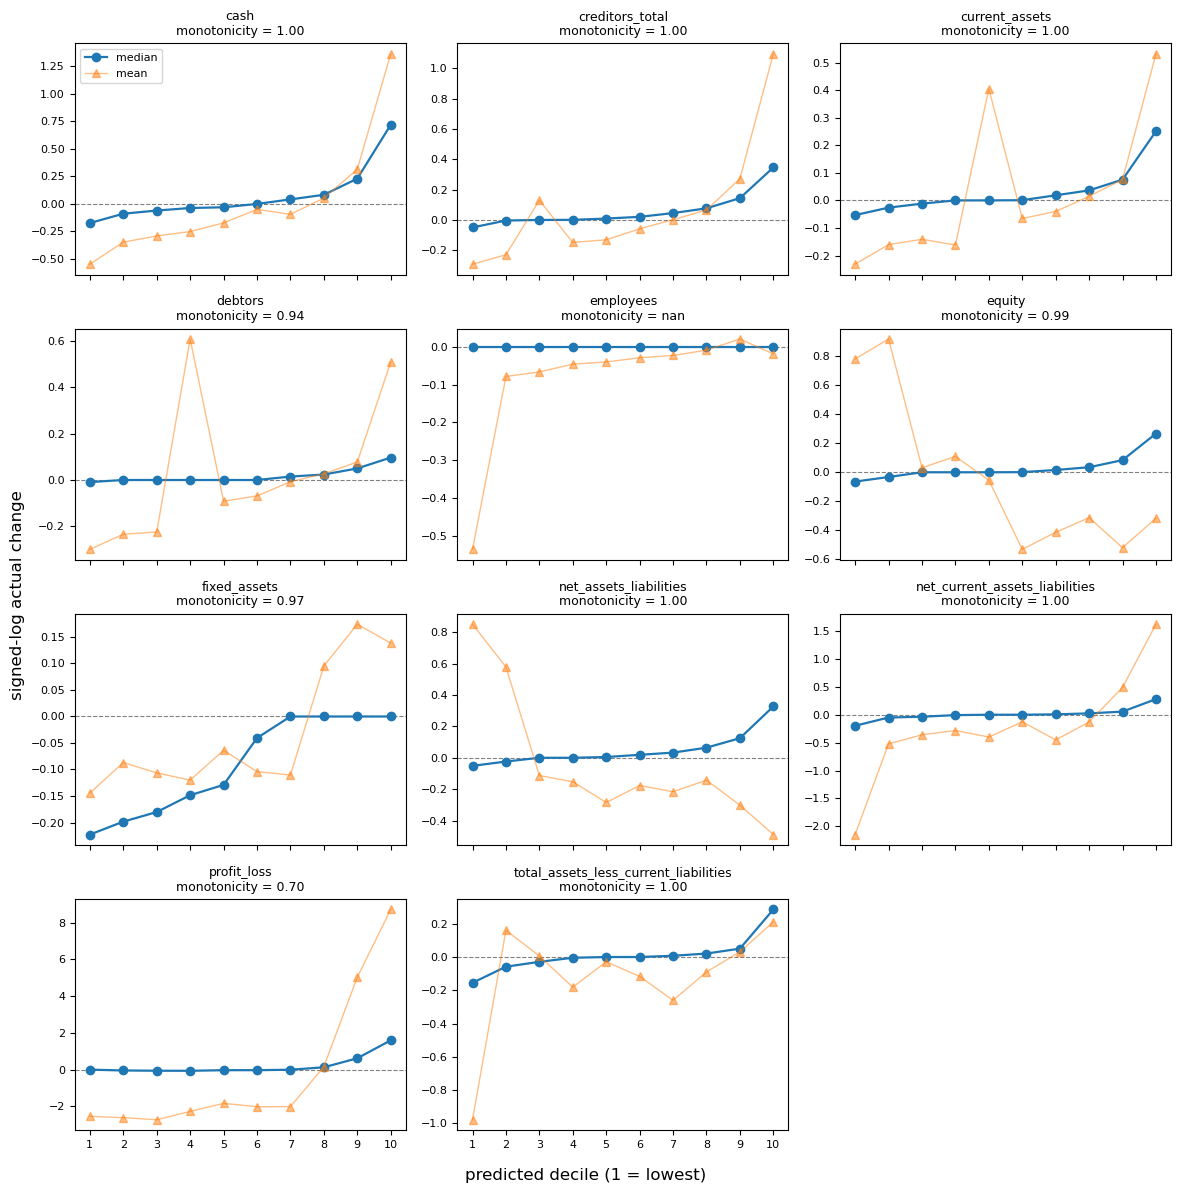

In [ ]:
n = len(profiles)
ncol = 3
nrow = int(np.ceil(n / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(4 * ncol, 3 * nrow), sharex=True)
axes = np.atleast_1d(axes).ravel()

for ax, (m, prof) in zip(axes, profiles.items()):
    x = prof.index.to_numpy()
    ax.axhline(0, color="grey", lw=0.8, ls="--", zorder=0)
    ax.plot(x, prof["median"], marker="o", lw=1.6, label="median")
    ax.plot(x, prof["mean"], marker="^", lw=1.0, alpha=0.5, label="mean")
    mono = summary.loc[summary.metric == m, "monotonicity"].iloc[0]
    ax.set_title(f"{m}\nmonotonicity = {mono:.2f}", fontsize=9)
    ax.set_xticks(x)
    ax.tick_params(labelsize=8)

for ax in axes[n:]:
    ax.set_visible(False)
axes[0].legend(fontsize=8)
fig.supxlabel("predicted decile (1 = lowest)")
fig.supylabel("signed-log actual change")
fig.tight_layout()
plt.show()

In [ ]:
def full_profile(y_true, y_pred, n_dec=10):
    """
    Full profile: median, quartiles and count per decile"""
    rank = pd.qcut(pd.Series(y_pred).rank(method="first"), n_dec, labels=False)
    prof = (pd.DataFrame({"decile": rank.values + 1, "y": y_true})
            .groupby("decile")["y"]
            .agg(median="median",
                 q25=lambda s: s.quantile(0.25),
                 q75=lambda s: s.quantile(0.75),
                 count="count"))
    prof["iqr"] = prof["q75"] - prof["q25"]
    prof["step"] = prof["median"].diff()
    return prof.round(4)


# for the shortlisted metrics
for m in ["creditors_total", "net_current_assets_liabilities",
          "current_assets", "cash", "fixed_assets"]:
    sub = loss_wide[[f"{m}__y_true", f"{m}__pred_L_quantile"]].dropna()
    print(f"\n===== {m}  n={len(sub):,} =====")
    print(full_profile(sub[f"{m}__y_true"].to_numpy(),
                       sub[f"{m}__pred_L_quantile"].to_numpy()).to_string())


===== creditors_total  n=74,018 =====
        median     q25     q75  count     iqr    step
decile                                               
1      -0.0494 -0.4613  0.1655   7402  0.6268     NaN
2      -0.0037 -0.2819  0.1732   7402  0.4551  0.0457
3       0.0000 -0.0891  0.1095   7402  0.1986  0.0037
4       0.0008 -0.1736  0.1652   7401  0.3389  0.0008
5       0.0093 -0.1876  0.2185   7402  0.4060  0.0085
6       0.0206 -0.1916  0.2766   7402  0.4681  0.0113
7       0.0452 -0.1942  0.3394   7401  0.5336  0.0247
8       0.0767 -0.1858  0.4672   7402  0.6531  0.0315
9       0.1437 -0.0996  0.7136   7402  0.8132  0.0670
10      0.3458  0.0000  1.6913   7402  1.6913  0.2021

===== net_current_assets_liabilities  n=74,815 =====
        median     q25     q75  count     iqr    step
decile                                               
1      -0.1982 -1.0632  0.1389   7482  1.2022     NaN
2      -0.0502 -0.5673  0.2450   7481  0.8123  0.1481
3      -0.0364 -0.4355  0.2239   7482  0.65

## 11. Model performance

In [9]:
# Model performance: pairwise accuracy and Spearman
# Both measure the same ranking ability; kept side by side for different audiences.

import numpy as np
import pandas as pd
from scipy.stats import spearmanr, kendalltau

wide = pd.read_csv(OUT_DIR / "loss_variant_predictions_wide.csv",
                   dtype={"CompanyNumber_norm": str})

PRED_COL = "pred_L_quantile"
N_PAIRS = 2_000_000

def discrimination_rate(y_true, y_pred, n_pairs=N_PAIRS, seed=0):
    """
    Among answerable pairs (y differs), how often does the model commit to an order?

    A low rate means the model outputs identical values for many companies, whose
    percentiles are then undefined. the scoring system cannot rank them however
    high pairwise_acc may look.
    """
    rng = np.random.default_rng(seed)
    n = len(y_true)
    i, j = rng.integers(0, n, n_pairs), rng.integers(0, n, n_pairs)
    answerable = (i != j) & (y_true[i] != y_true[j])
    if answerable.sum() == 0:
        return np.nan
    return float((y_pred[i[answerable]] != y_pred[j[answerable]]).mean())

In [ ]:
def ranking_performance(wide, metric, pred_col=PRED_COL):
    """
    Ranking ability for one metric.

    Pairwise accuracy = (Kendall tau-b + 1) / 2. The accuracy rate of the model when it is willing to commit. 
    Computed via kendalltau because enumerating all pairs of ~74k companies would require 2.7 billion 
    comparisons.

    tau-b excludes two kinds of pair: those tied in y_true (unanswerable, fair to drop) 
    and those tied in y_pred (the model declining to discriminate, which the exclusion silently forgives). 
    Hence it must be read alongside the discrimination rate.
    
    variant='b' excludes tied pairs from the denominator — essential for employees (73% zero change) 
    and fixed_assets (24%), where ties would otherwise drag the accuracy mechanically toward 50%.
    """
    cols = [f"{metric}__y_true", f"{metric}__{pred_col}"]
    if not all(c in wide.columns for c in cols):
        return None

    sub = wide[cols].dropna()
    if len(sub) < 200:
        return None

    y_true = sub[cols[0]].to_numpy()
    y_pred = sub[cols[1]].to_numpy()

    tau = kendalltau(y_true, y_pred, variant="b").statistic
    acc = (tau + 1) / 2 if np.isfinite(tau) else np.nan
    disc = discrimination_rate(y_true, y_pred)

    return {
        "metric": metric,
        "n": len(sub),
        "zero_frac": float((y_true == 0).mean()),
        "discrim_rate": disc,
        "pairwise_acc": acc,
        # effective ranking ability, counting abstention as no better than chance
        "effective_acc": 0.5 + disc * (acc - 0.5) if np.isfinite(acc) else np.nan,
        "spearman": spearmanr(y_true, y_pred).statistic,
    }


In [12]:
metrics = sorted({c.split("__")[0] for c in wide.columns if c.endswith("__y_true")})

rows = [r for m in metrics if (r := ranking_performance(wide, m)) is not None]
performance = (pd.DataFrame(rows)
               .sort_values("effective_acc", ascending=False)
               .round(4)
               .reset_index(drop=True))

print("discrim_rate : among answerable pairs, share where the model commits to an order")
print("pairwise_acc : accuracy when it does commit (0.5 = chance)")
print("effective_acc: combined: chance of ordering two differing companies correctly")
# zero_frac: proportion of true change exactly zero, high values indicating low discrimination
performance

discrim_rate : among answerable pairs, share where the model commits to an order
pairwise_acc : accuracy when it does commit (0.5 = chance)
effective_acc: combined: chance of ordering two differing companies correctly


,metric,n,zero_frac,discrim_rate,pairwise_acc,effective_acc,spearman
0,fixed_assets,40192,0.2399,0.9908,0.5984,0.5975,0.2763
1,profit_loss,2916,0.0302,1.0000,0.5908,0.5908,0.2668
2,cash,31753,0.0406,1.0000,0.5846,0.5846,0.2462
3,creditors_total,74018,0.0652,1.0000,0.5791,0.5791,0.2298
4,total_assets_less_current_liabilities,70435,0.0618,0.9992,0.5662,0.5661,0.1857
5,net_current_assets_liabilities,74815,0.0548,0.9994,0.5612,0.5612,0.1748
6,current_assets,69809,0.0490,0.9995,0.5535,0.5535,0.1562
7,net_assets_liabilities,67001,0.0608,0.9998,0.5513,0.5513,0.1428
8,equity,78768,0.1274,0.9928,0.5482,0.5478,0.1295
9,debtors,26618,0.1121,0.9984,0.5472,0.5472,0.1395
